In [31]:
# --- 1. Environment Initialization ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn plotting style for clean, readable white-grid backgrounds
sns.set_theme(style="whitegrid")
# Default all generated figures to a wide 12x6 aspect ratio
plt.rcParams['figure.figsize'] = (12, 6)

In [32]:
# --- 2. Data Loading & Processing ---
CSV_FILE = "test-data.csv"
df = pd.read_csv(CSV_FILE)

# Ensure raw voltage columns are strict numeric types (converting errors or 'FAILED' to NaN)
cols_to_clean = ['CH1_Vpp', 'CH4_Vpp']
for col in cols_to_clean:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Add a human-readable frequency label for graphing (e.g., "10.0 MHz") [cite: 14]
df['Freq_Label'] = (df['Frequency_Hz'] / 1e6).astype(str) + ' MHz'

# Calculate RF Gain in Decibels (dB).
# Using np.errstate to suppress division-by-zero warnings on Crosstalk pins where CH4_Vpp is near 0[cite: 16, 17].
with np.errstate(divide='ignore', invalid='ignore'):
    df['Gain_dB'] = 20 * np.log10(df['CH4_Vpp'] / df['CH1_Vpp'])

# --- Split the Dataset ---
# Signal Integrity Data: TX and RX are on the exact same trace [cite: 20, 21, 22]
df_main = df[df['TX_Pin'] == df['RX_Pin']].copy()

# Crosstalk Data: TX is injecting a signal, but RX is listening on a neighboring trace [cite: 23]
df_cross = df[df['TX_Pin'] != df['RX_Pin']].copy()

display(df.head())

,Frequency_Hz,TX_Pin,TX_Signal,RX_Pin,RX_Signal,CH1_Vpp,CH4_Vpp,Attenuation_Pct,Phase_Shift_Deg,Freq_Label,Gain_dB
0,100000,8,CLK,8,CLK,3.3,3.30,100.0,0.1,0.1 MHz,0.000000
1,100000,8,CLK,6,A1,3.3,0.01,0.3,0.0,0.1 MHz,-50.370279
2,100000,8,CLK,7,~WAIT~,3.3,0.01,0.3,0.0,0.1 MHz,-50.370279
3,100000,8,CLK,9,~MREQ~,3.3,0.01,0.3,0.0,0.1 MHz,-50.370279
4,100000,8,CLK,10,MCLK,3.3,0.00,0.0,0.0,0.1 MHz,-inf


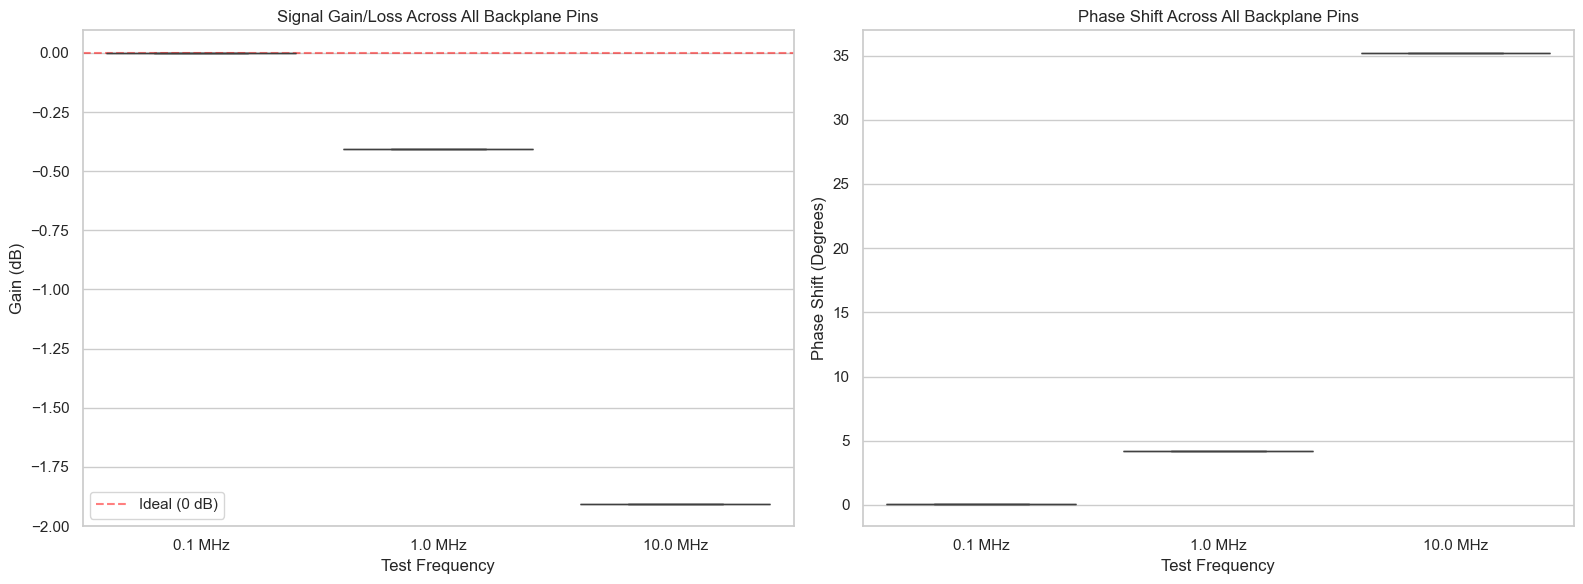

In [33]:
# --- 3. Global Signal Integrity Summary ---
# Visualizes the total spread of signal degradation across the entire backplane.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot A: Gain/Loss Spread
sns.boxplot(data=df_main, x='Freq_Label', y='Gain_dB', hue='Freq_Label', palette="Blues", legend=False, ax=axes[0])
axes[0].set_title("Signal Gain/Loss Across All Backplane Pins")
axes[0].set_ylabel("Gain (dB)")
axes[0].set_xlabel("Test Frequency")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5, label="Ideal (0 dB)")
axes[0].legend()

# Subplot B: Phase Shift Spread
# (If Phase_Shift_Deg was recorded in the CSV)
if 'Phase_Shift_Deg' in df_main.columns:
    sns.boxplot(data=df_main, x='Freq_Label', y='Phase_Shift_Deg', hue='Freq_Label', palette="Oranges", legend=False, ax=axes[1])
    axes[1].set_title("Phase Shift Across All Backplane Pins")
    axes[1].set_ylabel("Phase Shift (Degrees)")
    axes[1].set_xlabel("Test Frequency")

plt.tight_layout()
plt.show()

In [34]:
# --- 4. Identify Worst Offenders ---
# Filters down to the highest frequency (10 MHz) and sorts to find the traces with the most dB loss.
df_main_10mhz = df_main[df_main['Frequency_Hz'] == 10_000_000].copy()

# Sort ascending by Gain_dB (The most negative number represents the highest signal loss)
worst_attenuation = df_main_10mhz.sort_values(by='Gain_dB', ascending=True).head(10)

print("--- Worst Performing Pins at 10 MHz (Signal Loss) ---")
display(worst_attenuation[['TX_Pin', 'TX_Signal', 'Gain_dB']])

--- Worst Performing Pins at 10 MHz (Signal Loss) ---


,TX_Pin,TX_Signal,Gain_dB
24,8,CLK,-1.905361
30,10,MCLK,-1.905361


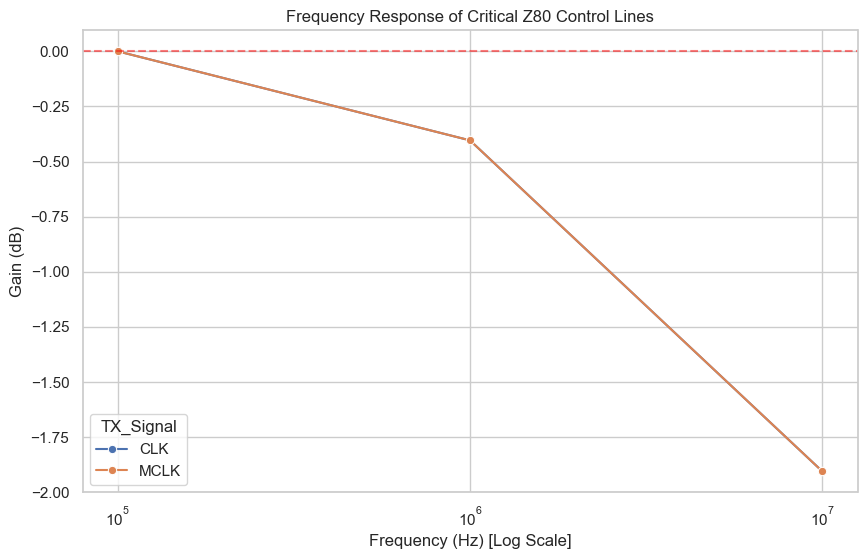

In [35]:
# --- 5. Frequency Response of Critical Lines ---
# Plots how specific, high-importance Z80 traces roll off as frequency increases.
critical_signals = ['MCLK', 'CLK', '~WAIT~', '~MREQ~']
df_crit = df_main[df_main['TX_Signal'].isin(critical_signals)]

if not df_crit.empty:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df_crit, x='Frequency_Hz', y='Gain_dB', hue='TX_Signal', marker='o')

    plt.xscale('log') # Log scale visually linearizes the 100k -> 1M -> 10M steps
    plt.title("Frequency Response of Critical Z80 Control Lines")
    plt.ylabel("Gain (dB)")
    plt.xlabel("Frequency (Hz) [Log Scale]")
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.show()
else:
    print("Critical signals not found in dataset. Check your signal names.")

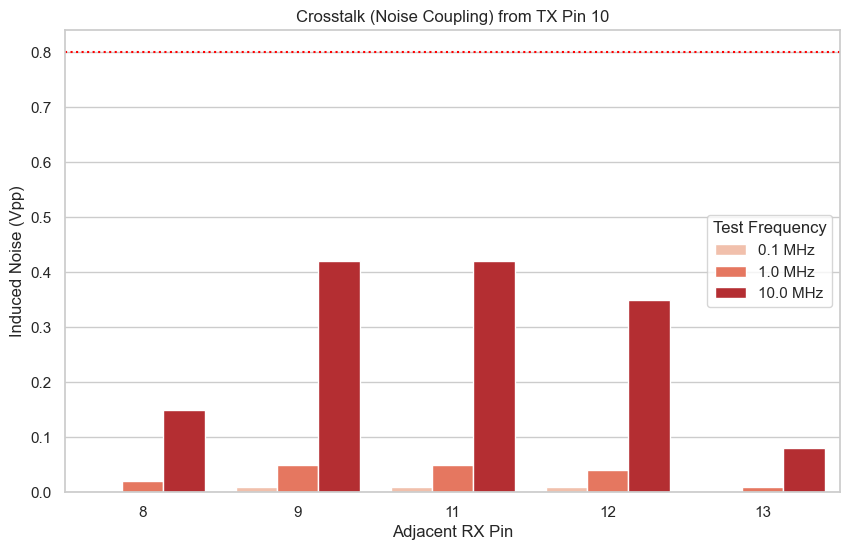

In [36]:
# --- 6. Crosstalk & Noise Coupling Analysis ---
# Visualizes how much voltage is bleeding onto adjacent pins from a target source pin[cite: 142].
TARGET_TX_PIN = 10

# Filter the crosstalk-only dataframe for our target source
crosstalk_data = df_cross[df_cross['TX_Pin'] == TARGET_TX_PIN]

if not crosstalk_data.empty:
    plt.figure(figsize=(10, 6))

    # Barplot groups adjacent RX pins by Frequency to show how high frequencies bleed worse[cite: 156, 157, 158, 159].
    sns.barplot(data=crosstalk_data, x='RX_Pin', y='CH4_Vpp', hue='Freq_Label', palette='Reds')

    plt.title(f"Crosstalk (Noise Coupling) from TX Pin {TARGET_TX_PIN}")
    plt.ylabel("Induced Noise (Vpp)")
    plt.xlabel("Adjacent RX Pin")
    plt.legend(title="Test Frequency")

    # Typical TTL Logic threshold is ~0.8V. If noise exceeds this, the Z80 might read a false logic state[cite: 137, 138].
    plt.axhline(0.8, color='red', linestyle=':', label="TTL Logic Low Threshold (0.8V)")

    plt.show()
else:
    print(f"No crosstalk data found for TX Pin {TARGET_TX_PIN}.")